In [ ]:
import pandas as pd

# Load dataset with encoding fix
spam = pd.read_csv("emails.csv", encoding="latin1")

# Display basic info
print("Dataset shape:", spam.shape)
print("\nColumn names:\n", spam.columns.tolist())
print("\nData types:\n", spam.dtypes)
print("\nPreview:\n")
spam.head()

Shape (rows, columns): (5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


text    object
spam     int64
dtype: object

In [ ]:
#Check duplicates and missing values
print("Number of duplicate rows:", spam.duplicated().sum())

# Count missing (NaN) values per column
print("\nMissing values per column:")
print(spam.isnull().sum())


Number of duplicate rows: 33

Missing values per column:
text    0
spam    0
dtype: int64


In [ ]:
#Clean the dataset
# make a copy
spam_clean = spam.copy()

#remove duplicate rows
spam_clean = spam_clean.drop_duplicates()

#clean the text
# fill empty spaces
# convert to lowercase
# remove extra spaces
# trailing spaces
spam_clean["text"] = (
    spam_clean["text"]
    .fillna("")                   
    .astype(str)                 
    .str.lower()                 
    .str.replace(r"\\s+", " ", regex=True) 
    .str.strip()                 
)

#ensure label column only contains 0 and 1
spam_clean = spam_clean[spam_clean["spam"].isin([0, 1])]

print("After cleaning:")
print("Rows:", spam_clean.shape[0])

display(spam_clean.head())


After cleaning:
Rows: 5695


,text,spam
0,subject: naturally irresistible your corporate...,1
1,subject: the stock trading gunslinger fanny i...,1
2,subject: unbelievable new homes made easy im ...,1
3,subject: 4 color printing special request add...,1
4,"subject: do not have money , get software cds ...",1


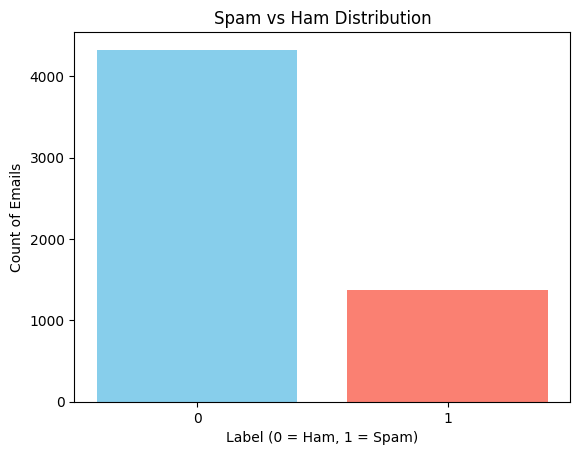

Counts:
spam
0    4327
1    1368
Name: count, dtype: int64


In [ ]:
#Visualize spam vs ham balance
import matplotlib.pyplot as plt

counts = spam_clean["spam"].value_counts().sort_index()

plt.bar(counts.index, counts.values, color=["skyblue", "salmon"])
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count of Emails")
plt.xticks([0, 1])
plt.show()

print("Counts:")
print(counts)


In [ ]:
#Split the dataset (80 / 10 / 10)
from sklearn.model_selection import train_test_split

# Separate features and labels
X = spam_clean[["text"]].copy()
y = spam_clean["spam"].copy()

#split into 80% train and 20% 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#split 20% into half validation, half test (10% + 10%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape,  y_test.shape)


Train: (4556, 1) (4556,)
Valid: (569, 1) (569,)
Test : (570, 1) (570,)


In [ ]:
#Save splits 
X_train.to_csv("spam_X_train.csv", index=False)
y_train.to_csv("spam_y_train.csv", index=False)
X_valid.to_csv("spam_X_valid.csv", index=False)
y_valid.to_csv("spam_y_valid.csv", index=False)
X_test.to_csv("spam_X_test.csv", index=False)
y_test.to_csv("spam_y_test.csv", index=False)

print("all save")


all save
